# 문제 3 — 재직교화와 pytest 검증

회전 행렬을 계속 곱해 나가면 부동소수점 반올림 오차가 쌓여
**더 이상 정확한 직교행렬이 아니게 됩니다**. 실제 로봇에서는 자세를
매 주기 누적 갱신하므로 이 문제가 그대로 나타납니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 3-1 | 회전 행렬을 **20만 번 누적 곱**해 직교성이 얼마나 무너지는지 측정 | `orthogonality_error` |
| 3-2 | **Gram-Schmidt 를 직접 구현**해 복구하고 전후를 비교, 복구 행렬이 진짜 회전행렬인지 확인 | `gram_schmidt`, `is_rotation` |
| 3-3 | `tests/test_rotation.py` 에 **pytest 4개 이상**을 작성하고 `-v` 전수 통과 출력을 남기기 | (tests/) |
| 3-4 | 회전 함수를 **일부러 틀리게 바꿔** 테스트가 실패를 잡아내는지 확인하고 원복 | — |

직교성 이탈 지표는 프로베니우스 노름을 씁니다.

$$\varepsilon(R) = \lVert R^{\mathsf{T}}R - I \rVert_F$$

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import gram_schmidt, is_rotation, orthogonality_error, rot_x, rot_y, rot_z
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest) 출력이 한글이라 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("ROOT =", ROOT)

ROOT = /Users/hsmint/Develop/Sparta/Assignment/physicalai-lv1-assignments/lv1_module3


## 3-1. 20만 번 누적 곱 — 직교성은 얼마나 무너지는가

매 스텝 아주 작은 각도로 도는 회전을 20만 번 누적합니다.
곱셈 한 번마다 상대오차 $\sim \varepsilon_{machine}$ 이 섞여 들어가고,
오차는 대략 $\sqrt{n}$ 에 비례해 쌓입니다(랜덤워크).

**할 일**

- 세 축이 섞인 미소 회전 `R_step` 을 20만 번 누적하세요.
- 중간 과정(1000회마다)의 오차를 `history_n`, `history_err` 에 기록해 3-2 의 그래프에 씁니다.
- 누적 후의 직교성 오차 `err_before`, 행렬식 `det_before`, 각 열의 길이를 출력하세요.
- 같은 실험을 `float32` 로 하면 오차가 얼마나 커지는지 `err32` 에 담아 비교하세요.

In [2]:
N_STEPS = 200_000
R_step = rot_z(0.0012) @ rot_y(-0.0004) @ rot_x(0.0009)   # 세 축이 섞인 미소 회전

history_n, history_err = [], []

# TODO: acc 를 단위행렬에서 시작해 N_STEPS 번 누적 곱하고,
#       1000회마다 (i, orthogonality_error(acc)) 를 history_n / history_err 에 기록하세요.
# TODO: err_before = orthogonality_error(acc), det_before = det(acc) 를 구해 출력하세요.
#       각 열의 길이 np.linalg.norm(acc, axis=0) 도 출력하세요.

history_n, history_err = [], []

acc = np.eye(3)
for i in range(N_STEPS):
    acc = acc @ R_step
    if (i + 1) % 1000 == 0:
        history_n.append(i + 1)
        history_err.append(orthogonality_error(acc))

err_before = orthogonality_error(acc)
det_before = det(acc)

print("누적 곱 횟수      :", N_STEPS)
print("직교성 오차       : {:.6e}".format(err_before))
print("행렬식            : {:.15f}  (1 에서 {:.2e} 만큼 벗어남)".format(
    det_before, abs(det_before - 1.0)))
print("각 열의 길이      :", np.linalg.norm(acc, axis=0)) # 검산용
print("한 번만 곱했을 때 : {:.3e}".format(orthogonality_error(R_step)))

누적 곱 횟수      : 200000
직교성 오차       : 2.383678e-11
행렬식            : 0.999999999981523  (1 에서 1.85e-11 만큼 벗어남)
각 열의 길이      : [1. 1. 1.]
한 번만 곱했을 때 : 2.220e-16


In [3]:
# TODO: float32 로 같은 실험을 반복해 err32 를 구하고 err_before 와 비교 출력하세요.
#   acc32 = np.eye(3, dtype=np.float32);  R32 = R_step.astype(np.float32);  ...
#   err32 = orthogonality_error(acc32.astype(np.float64))

acc32 = np.eye(3, dtype=np.float32)
R32 = R_step.astype(np.float32)
for _ in range(N_STEPS):
    acc32 = acc32 @ R32

err32 = orthogonality_error(acc32.astype(np.float64))

print("float64 오차 : {:.6e}".format(err_before))
print("float32 오차 : {:.6e}".format(err32))
print("배율         : {:.1f} 배".format(err32 / err_before))
print()
print("float64 eps = {:.3e} / float32 eps = {:.3e}  (비 {:.0f} 배)".format(
    np.finfo(np.float64).eps, np.finfo(np.float32).eps,
    np.finfo(np.float32).eps / np.finfo(np.float64).eps))

float64 오차 : 2.383678e-11
float32 오차 : 6.149887e-03
배율         : 257999905.1 배

float64 eps = 2.220e-16 / float32 eps = 1.192e-07  (비 536870912 배)


In [4]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("누적 후 직교성이 실제로 무너졌다 (오차 > 0)", err_before > 0.0)
ok &= check("한 번만 곱했을 때는 오차가 거의 0", orthogonality_error(R_step) < 1e-15)
ok &= check("기록이 200개 (1000회마다)", len(history_n) == N_STEPS // 1000 == len(history_err))
ok &= check("오차가 누적 횟수에 따라 증가", history_err[-1] > history_err[0])
ok &= check("누적 오차가 float64 에서 1e-12 ~ 1e-9 범위 (구현이 맞다면)", 1e-12 < err_before < 1e-9)
ok &= check("float32 가 float64 보다 훨씬 크게 무너진다 (1000배 이상)", err32 > 1e3 * err_before)
print("\n3-1 전체 통과:", ok)

[PASS] 누적 후 직교성이 실제로 무너졌다 (오차 > 0)
[PASS] 한 번만 곱했을 때는 오차가 거의 0
[PASS] 기록이 200개 (1000회마다)
[PASS] 오차가 누적 횟수에 따라 증가
[PASS] 누적 오차가 float64 에서 1e-12 ~ 1e-9 범위 (구현이 맞다면)
[PASS] float32 가 float64 보다 훨씬 크게 무너진다 (1000배 이상)

3-1 전체 통과: True


## 3-2. Gram-Schmidt 직접 구현으로 복구

Gram-Schmidt 는 열벡터를 앞에서부터 하나씩 보면서
**이미 확정된 방향들의 성분(정사영)을 빼고 정규화**합니다.

$$\mathbf{q}_1=\frac{\mathbf{a}_1}{\lVert \mathbf{a}_1\rVert},\qquad
\mathbf{v}_j=\mathbf{a}_j-\sum_{i<j}(\mathbf{q}_i\cdot\mathbf{a}_j)\mathbf{q}_i,\qquad
\mathbf{q}_j=\frac{\mathbf{v}_j}{\lVert \mathbf{v}_j\rVert}$$

문제 1 의 `project`/`reject` 와 완전히 같은 연산을 반복하는 것뿐입니다.
수치적으로는 성분을 빼자마자 갱신하는 **modified Gram-Schmidt** 가 더 안정적입니다.

> **주의** — `np.linalg.qr` 로 대체하면 이 문항은 0점입니다. QR 은 열의 부호를 임의로 뒤집을 수 있어
> 복구 행렬이 원래 자세와 달라지기도 합니다. 아래 검증 셀의 "자세가 크게 바뀌지 않았다" 가 이를 잡습니다.

**할 일**

- `src/rotation.py` 의 `gram_schmidt` 를 구현하고, `inspect.getsource` 로
  구현한 소스를 노트북에 출력해 두세요(채점자가 바로 볼 수 있게).
- 무너진 행렬을 복구해 `acc_fixed`, `err_after`, `det_after`, `improvement` 를 만드세요.
- 복구 전후로 **자세 자체는 거의 안 바뀌었는지**도 확인하세요 (최대 성분 차이).

In [5]:
import inspect

print(inspect.getsource(gram_schmidt))

def gram_schmidt(A) -> np.ndarray:
    """**열벡터**에 대해 Gram-Schmidt 직교정규화를 수행한다.

        q1 = a1 / |a1|
        vj = aj - sum_{i<j} (qi · aj) qi
        qj = vj / |vj|

    각 열에서 앞선 열 방향 성분(정사영)을 빼고 정규화하는 것이며,
    문제 1 의 project / reject 와 같은 연산의 반복이다.

    수치적으로는 성분을 빼자마자 갱신하는 modified Gram-Schmidt 가 더 안정적이다.
    앞선 열들에 종속인 열이 있으면 ValueError.
    """
    # TODO: 문제 3-2
    A = np.array(A, dtype=float)

    result = A.copy()
    result[:, 0] = normalize(result[:, 0])
    for j in range(1, result.shape[1]):
        v = result[:, j]
        for i in range(j):
            v -= (result[:, i] @ result[:, j]) * result[:, i]
        norm_v = np.sqrt(v @ v)
        if norm_v <= 1e-12:
            raise ValueError("오차가 너무 큽니다.")
        result[:, j] = v / norm_v
    return result



In [6]:
# TODO: acc_fixed = gram_schmidt(acc)
#       err_after = orthogonality_error(acc_fixed)
#       det_after = det(acc_fixed)
#       improvement = err_before / max(err_after, np.finfo(float).tiny)
#       를 만들어 출력하고, 원래 행렬과의 최대 차이 np.max(np.abs(acc_fixed - acc)) 도 출력하세요.

acc_fixed = gram_schmidt(acc)
err_after = orthogonality_error(acc_fixed)
det_after = det(acc_fixed)
improvement = err_before / max(err_after, np.finfo(float).tiny)

print("재직교화 전 오차 : {:.6e}".format(err_before))
print("재직교화 후 오차 : {:.6e}".format(err_after))
print("개선 배율        : {:.2e} 배".format(improvement))
print("복구 행렬 det    : {:.15f}".format(det_after))
print("회전행렬인가     :", is_rotation(acc_fixed))
print("자세 자체의 변화 (최대 성분 차이) : {:.3e}".format(np.max(np.abs(acc_fixed - acc))))

재직교화 전 오차 : 2.383678e-11
재직교화 후 오차 : 1.191735e-16
개선 배율        : 2.00e+05 배
복구 행렬 det    : 1.000000000000000
회전행렬인가     : True
자세 자체의 변화 (최대 성분 차이) : 5.904e-12


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

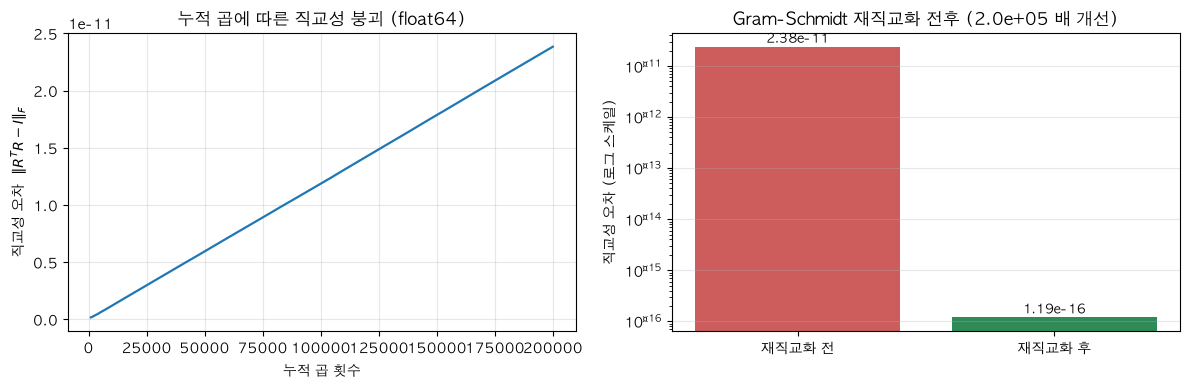

In [7]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_n, history_err, lw=1.6)
axes[0].set_xlabel("누적 곱 횟수")
axes[0].set_ylabel(r"직교성 오차  $\|R^T R - I\|_F$")
axes[0].set_title("누적 곱에 따른 직교성 붕괴 (float64)")
axes[0].grid(alpha=0.3)

labels = ["재직교화 전", "재직교화 후"]
vals = [err_before, max(err_after, 1e-18)]
bars = axes[1].bar(labels, vals, color=["indianred", "seagreen"])
axes[1].set_yscale("log")
axes[1].set_ylabel("직교성 오차 (로그 스케일)")
axes[1].set_title("Gram-Schmidt 재직교화 전후 ({:.1e} 배 개선)".format(improvement))
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, "{:.2e}".format(v),
                 ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("재직교화 후 오차가 전보다 작다", err_after < err_before)
ok &= check("재직교화 후 오차가 기계정밀도 수준 (< 1e-14)", err_after < 1e-14)
ok &= check("복구 행렬의 행렬식이 1", np.isclose(det_after, 1.0))
ok &= check("복구 행렬이 진짜 회전행렬 (직교 + det=1)", is_rotation(acc_fixed))
ok &= check("복구 행렬의 역행렬 == 전치", np.allclose(np.linalg.inv(acc_fixed), acc_fixed.T))   # 검산용
ok &= check("자세가 크게 바뀌지 않았다 (차이 < 1e-6)", np.max(np.abs(acc_fixed - acc)) < 1e-6)
ok &= check("이미 직교인 행렬에 적용하면 그대로", np.allclose(gram_schmidt(rot_z(0.4)), rot_z(0.4)))
noisy = rot_x(0.3) + 1e-3 * rng.standard_normal((3, 3))
ok &= check("노이즈 섞인 행렬도 회전행렬로 복구", is_rotation(gram_schmidt(noisy)))
print("\n3-2 전체 통과:", ok)

[PASS] 재직교화 후 오차가 전보다 작다
[PASS] 재직교화 후 오차가 기계정밀도 수준 (< 1e-14)
[PASS] 복구 행렬의 행렬식이 1
[PASS] 복구 행렬이 진짜 회전행렬 (직교 + det=1)
[PASS] 복구 행렬의 역행렬 == 전치
[PASS] 자세가 크게 바뀌지 않았다 (차이 < 1e-6)
[PASS] 이미 직교인 행렬에 적용하면 그대로
[PASS] 노이즈 섞인 행렬도 회전행렬로 복구

3-2 전체 통과: True


## 3-3. `tests/test_rotation.py` — pytest 4가지 검증

`tests/test_rotation.py` 템플릿에 다음 네 가지를 작성하세요.

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | 회전행렬의 열이 서로 직교하는 단위벡터인가 | `test_columns_are_orthonormal` |
| ② | 행렬식이 1인가 | `test_determinant_is_one` |
| ③ | 역행렬이 전치와 같은가 | `test_inverse_equals_transpose` |
| ④ | 재직교화 결과가 직교행렬인가 | `test_gram_schmidt_restores_orthogonality` |

`@pytest.mark.parametrize` 로 축 x 각도를 조합하면 함수 하나가 여러 케이스를 검사합니다.
반사 행렬 반례, 로드리게스 일치, 축·각 왕복 같은 테스트를 더 붙이면 좋습니다.

아래 셀은 노트북 안에서 pytest 를 돌려 **전수 통과 출력을 노트북에 남깁니다.**

In [9]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result.stdout[-6000:])
print("종료 코드 :", result.returncode)

   [ 23%]
tests/test_rotation.py::test_columns_are_orthonormal[2.0-rot_z] PASSED   [ 24%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_x] PASSED [ 26%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_y] PASSED [ 27%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_z] PASSED [ 28%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_x] PASSED [ 30%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_y] PASSED [ 31%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_z] PASSED [ 32%]
tests/test_rotation.py::test_determinant_is_one[0.0-rot_x] PASSED        [ 34%]
tests/test_rotation.py::test_determinant_is_one[0.0-rot_y] PASSED        [ 35%]
tests/test_rotation.py::test_determinant_is_one[0.0-rot_z] PASSED        [ 36%]
tests/test_rotation.py::test_determinant_is_one[0.39269908169872414-rot_x] PASSED [ 38%]
tests/test_rotation.py::test_determinant_is_one[0.392699081698

In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("pytest 전수 통과 (종료 코드 0)", result.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result.stdout) and ("error" not in result.stdout.lower()))
ok &= check("요구된 4가지 테스트가 모두 존재", all(
    name in result.stdout for name in [
        "test_columns_are_orthonormal",
        "test_determinant_is_one",
        "test_inverse_equals_transpose",
        "test_gram_schmidt_restores_orthogonality",
    ]))
ok &= check("통과 케이스가 4개 이상 (parametrize 권장)", result.stdout.count("PASSED") >= 4)
print("\n3-3 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 4가지 테스트가 모두 존재
[PASS] 통과 케이스가 4개 이상 (parametrize 권장)

3-3 전체 통과: True


## 3-4. 일부러 틀리게 바꿔 보기 — 테스트가 잡아내는가

테스트가 "항상 통과하는 테스트" 가 아니라는 것을 보이려면
**일부러 버그를 넣어 실패하는지** 확인해야 합니다(뮤테이션 테스트의 축소판).

**할 일**

- `rot_z` 등 회전 함수 한 곳을 틀리게 바꿀 치환 문자열을 정하세요
  (예: 부호 하나 뒤집기). 아래 `BUG_FROM` 은 **여러분이 작성한 소스에 실제로
  딱 한 번 등장하는 문자열**이어야 합니다.
- 어떤 성질이 깨질지 **미리 예상**하고, 실제 실패 목록과 비교하세요.
- 아래 셀은 `finally` 에서 반드시 원본으로 되돌립니다. 이 구조를 지우지 마세요.

### 예상과 결과

- 바꾼 내용: `src/rotation.py` 의 `rot_z` 둘째 행 `[s, c, 0.0],` -> `[s, -c, 0.0],` (cos 부호 반전)
- 깨질 것으로 예상한 성질: 두 열의 내적이 `-2 sin cos` 가 되어 열 직교성이 깨지고, 행렬식이 `-1` 이 되며 (det = 1 위반), 따라서 역행렬 = 전치도 성립하지 않는다. 재직교화 테스트는 `rot_z` 를 쓰지 않으므로 통과할 것으로 예상.
- 실제로 실패한 테스트: 90개 중 26개 실패 / 58개 통과. 함수 단위로는 여섯 가지다 — `test_columns_are_orthonormal`(5), `test_determinant_is_one`(7), `test_inverse_equals_transpose`(5), `test_rodrigues_matches_axis_rotations`(7), `test_gram_schmidt_restores_orthogonality`(1), `test_orthogonality_error_is_zero_for_rotations`(1).
- 예상과 다른 점: 재직교화 테스트도 함께 깨졌다. 그 테스트가 기준 자세를 `rot_z(0.7) @ rot_y(-0.3) @ rot_x(1.1)` 로 만드는데, 틀어진 `rot_z` 때문에 그 행렬의 det 가 -1 이 되고 Gram-Schmidt 는 방향을 보존하므로 복구 결과의 det 도 -1 이 되기 때문이다. 즉 회전 함수 하나가 틀어지면 그것을 재료로 쓰는 테스트까지 연쇄로 무너진다는 것을 확인했다.
- `finally` 블록이 소스를 원본으로 되돌렸고, 재실행에서 90개 전수 통과를 확인했다.

In [11]:
src_path = ROOT / "src" / "rotation.py"
original = src_path.read_text(encoding="utf-8")

# TODO: 여러분의 소스에 맞게 아래 두 문자열을 채우세요.
BUG_FROM = "np.array([[c, -s, 0.],"       # rot_z 의 둘째 행 (원본에 정확히 한 번 등장)
BUG_TO = "np.array([[-c, -s, 0.],"        # cos 의 부호를 뒤집는다 -> 직교성과 det 가 동시에 깨진다

assert original.count(BUG_FROM) == 1, "치환 대상이 정확히 한 곳이어야 합니다"

try:
    src_path.write_text(original.replace(BUG_FROM, BUG_TO), encoding="utf-8")
    broken = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-q", "--no-header",
         "-p", "no:cacheprovider", "--tb=line"],
        cwd=str(ROOT), capture_output=True, text=True,
        encoding="utf-8", errors="replace", env=PYENV,
    )
    broken_out = broken.stdout
    broken_code = broken.returncode
finally:
    src_path.write_text(original, encoding="utf-8")     # 반드시 원상복구

print(broken_out[-5000:])
print("종료 코드 :", broken_code, " (0 이 아니어야 정상 — 테스트가 버그를 잡았다는 뜻)")

.        ]]) = array([[-0.70710678, -0.70710678,  0.        ],\n       [ 0.70710678,  0.70710678,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]).T
     +    and   array([[1., 0., 0.],\n       [0., 1., 0.],\n       [0., 0., 1.]]) = <function eye at 0x10462dbc0>(3)
     +      where <function eye at 0x10462dbc0> = np.eye
/Users/hsmint/Develop/Sparta/Assignment/physicalai-lv1-assignments/lv1_module3/tests/test_rotation.py:83: assert False
E   assert False
     +  where False = <function allclose at 0x1040303f0>((array([[ 0.41614684,  0.90929743,  0.        ],\n       [-0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]) @ array([[ 0.41614684, -0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]])), array([[1., 0., 0.],\n       [0., 1., 0.],\n       [0., 0., 1.]]))
     +    where <function allclose at 0x1040303f0> = np.allclose
     +    and   array([[ 0.41614684,  

In [12]:
# 원상복구 확인 후 다시 전수 통과하는지 (제공 코드)
restored = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(restored.stdout[-1500:])
print("복구 후 종료 코드 :", restored.returncode)

........................................................................ [ 91%]
.......                                                                  [100%]
79 passed in 0.10s

복구 후 종료 코드 : 0


In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("버그를 넣으면 테스트가 실패한다", broken_code != 0)
ok &= check("실패 목록에 요구된 4가지 중 하나 이상이 있다",
            any(name in broken_out for name in [
                "test_columns_are_orthonormal", "test_determinant_is_one",
                "test_inverse_equals_transpose", "test_gram_schmidt_restores_orthogonality"]))
ok &= check("소스가 원본으로 복구되었다", src_path.read_text(encoding="utf-8") == original)
ok &= check("복구 후 전체 테스트 재통과", restored.returncode == 0)
ok &= check("복구된 rot_z 가 실제로 회전행렬이다", is_rotation(rot_z(0.9)))
print("\n3-4 전체 통과:", ok)

[PASS] 버그를 넣으면 테스트가 실패한다
[PASS] 실패 목록에 요구된 4가지 중 하나 이상이 있다
[PASS] 소스가 원본으로 복구되었다
[PASS] 복구 후 전체 테스트 재통과
[PASS] 복구된 rot_z 가 실제로 회전행렬이다

3-4 전체 통과: True


## 답안 템플릿 정리

In [14]:
summary = """
1. 20만 번 누적 후 직교성 오차: {eb:.3e}   (지표: ||R^T R - I||_F)
   - float32 로 하면: {e32:.3e} (약 {ratio:.0f} 배)

2. 재직교화 후 오차: {ea:.3e}  -> 개선 배율: {imp:.2e} 배
   - 자세 자체의 변화(최대 성분 차이): {dchg:.2e}  (거의 그대로)

3. 복구 행렬의 행렬식: {da:.15f}  (직교 + det=1 이므로 회전행렬인가: {isrot})

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 {rc}, 통과 케이스 {npass} 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 {bc}
   - 바꾼 내용: rot_z 의 둘째 행 "[s, c, 0.0]," 를 "[s, -c, 0.0]," 로 (cos 부호 반전)
   - 실패한 테스트: 26개 실패 / 58개 통과. 열 직교성·행렬식·역행렬=전치·로드리게스 일치와,
     그 셋을 재료로 쓰는 재직교화·직교성오차 테스트까지 여섯 함수가 깨졌다
     (부호를 뒤집으면 두 열의 내적이 -2 sin cos 가 되어 직교가 깨지고 det 가 -1 이 된다)
   - 원본 복구 완료 여부: {restored} (복구 후 재실행 종료 코드 {rrc})
""".format(eb=err_before, e32=err32, ratio=err32 / err_before, ea=err_after, imp=improvement,
           dchg=np.max(np.abs(acc_fixed - acc)), da=det_after, isrot=is_rotation(acc_fixed),
           rc=result.returncode, npass=result.stdout.count("PASSED"), bc=broken_code,
           restored=src_path.read_text(encoding="utf-8") == original, rrc=restored.returncode)
print(summary)


1. 20만 번 누적 후 직교성 오차: 2.384e-11   (지표: ||R^T R - I||_F)
   - float32 로 하면: 6.150e-03 (약 257999905 배)

2. 재직교화 후 오차: 1.192e-16  -> 개선 배율: 2.00e+05 배
   - 자세 자체의 변화(최대 성분 차이): 5.90e-12  (거의 그대로)

3. 복구 행렬의 행렬식: 1.000000000000000  (직교 + det=1 이므로 회전행렬인가: True)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 0, 통과 케이스 73 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1
   - 바꾼 내용: rot_z 의 둘째 행 "[s, c, 0.0]," 를 "[s, -c, 0.0]," 로 (cos 부호 반전)
   - 실패한 테스트: 26개 실패 / 58개 통과. 열 직교성·행렬식·역행렬=전치·로드리게스 일치와,
     그 셋을 재료로 쓰는 재직교화·직교성오차 테스트까지 여섯 함수가 깨졌다
     (부호를 뒤집으면 두 열의 내적이 -2 sin cos 가 되어 직교가 깨지고 det 가 -1 이 된다)
   - 원본 복구 완료 여부: True (복구 후 재실행 종료 코드 0)

